# Desempenho Escolar de Estudantes — EDA e Modelagem de ML

**Disciplina:** CMPINAM – Introdução ao Aprendizado de Máquina  
**Professor:** Everton Meyer da Silva  
**Instituição:** Instituto Federal de Educação, Ciência e Tecnologia — Câmpus Campinas  
**Dataset:** Student Performance Dataset (UCI Machine Learning Repository)  
**Integrantes:** Antonio Messias (CP 3026451) · Alan Rocha (CP 3025039)

---

---
# PARTE 1 — Análise Exploratória de Dados (EDA)
---

## 1. Entendimento do Problema

O desempenho escolar de estudantes é um tema central em políticas educacionais ao redor do mundo.
Identificar os fatores que mais influenciam o rendimento acadêmico pode orientar intervenções pedagógicas
mais eficazes, ajudar professores a identificar alunos em risco de reprovação e contribuir para políticas
públicas de educação mais bem direcionadas.

Este trabalho analisa o **Student Performance Dataset**, coletado em duas escolas secundárias de Portugal
durante o ano letivo de 2005–2006. O dataset reúne informações demográficas, socioeconômicas, comportamentais
e de hábitos de estudo de estudantes das disciplinas de **Matemática** e **Língua Portuguesa**, além de suas
notas ao longo do ano.

A relevância do problema é clara: a evasão escolar e o baixo desempenho acadêmico têm impactos profundos
na trajetória de vida dos jovens e nos índices de desenvolvimento humano. Entender quais variáveis —
como consumo de álcool, tempo de estudo, estrutura familiar ou escolaridade dos pais — estão associadas
ao desempenho final pode gerar insights valiosos tanto para educadores quanto para formuladores de políticas.

### Perguntas/Hipóteses que guiarão a EDA

1. Como se distribui a nota final (G3) dos estudantes em cada disciplina?
2. Estudantes que desejam cursar o ensino superior têm notas finais melhores?
3. O tempo de estudo semanal está associado a notas mais altas?
4. O consumo de álcool (nos dias úteis e fins de semana) afeta o desempenho escolar?
5. A escolaridade dos pais influencia as notas dos filhos?
6. Há diferença de desempenho entre estudantes do sexo feminino e masculino?
7. O número de reprovações anteriores está correlacionado com a nota final?
8. Estudantes com mais faltas tendem a ter notas finais mais baixas?
9. Existe uma progressão consistente entre G1, G2 e G3 ao longo do ano?
10. O tipo de endereço (urbano vs. rural) influencia o desempenho?

## 2. Descrição da Base de Dados

**Fonte:** [UCI Machine Learning Repository — Student Performance Dataset](https://archive.ics.uci.edu/ml/datasets/student+performance)  
**Referência:** P. Cortez e A. Silva. *Using Data Mining to Predict Secondary School Student Performance.* EUROSIS, 2008.

O dataset contém dados de estudantes de duas escolas secundárias portuguesas (Gabriel Pereira — GP, e
Mousinho da Silveira — MS), coletados via questionários escolares. Existem dois arquivos:

- `student-mat.csv` — 395 estudantes de **Matemática**
- `student-por.csv` — 649 estudantes de **Língua Portuguesa**

Cada linha representa **um estudante** em uma disciplina específica. Os atributos se dividem em:

| Grupo | Exemplos de atributos |
|---|---|
| Demográficos | `sex`, `age`, `address`, `famsize`, `Pstatus` |
| Socioeconômicos | `Medu`, `Fedu`, `Mjob`, `Fjob` |
| Escolares | `school`, `reason`, `studytime`, `failures`, `schoolsup`, `paid` |
| Comportamentais | `goout`, `Dalc`, `Walc`, `romantic`, `activities` |
| Notas | `G1` (1º bimestre), `G2` (2º bimestre), `G3` (nota final) |

As notas vão de 0 a 20 (escala portuguesa). **G3 é a variável-alvo** para fins preditivos futuros.

## 3. Importações e Carregamento dos Dados

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

# Carregamento
mat = pd.read_csv('student-mat.csv', sep=';')
por = pd.read_csv('student-por.csv', sep=';')

print(f'Matemática: {mat.shape[0]} estudantes, {mat.shape[1]} atributos')
print(f'Português:  {por.shape[0]} estudantes, {por.shape[1]} atributos')

Matemática: 395 estudantes, 33 atributos
Português:  649 estudantes, 33 atributos


## 4. Limpeza e Preparação Inicial dos Dados

In [25]:
# Verificação de valores nulos
print('=== Valores nulos ===')
print('Matemática:', mat.isnull().sum().sum())
print('Português: ', por.isnull().sum().sum())

# Verificação de duplicatas
print('\n=== Duplicatas ===')
print('Matemática:', mat.duplicated().sum())
print('Português: ', por.duplicated().sum())

=== Valores nulos ===
Matemática: 0
Português:  0

=== Duplicatas ===
Matemática: 0
Português:  0


In [26]:
# Verificação de valores absurdos nas notas (fora do intervalo 0–20)
for df, nome in [(mat, 'Matemática'), (por, 'Português')]:
    for col in ['G1', 'G2', 'G3']:
        fora = df[(df[col] < 0) | (df[col] > 20)]
        if len(fora) > 0:
            print(f'[{nome}] {col}: {len(fora)} valores fora do intervalo')

# Verificação de idades fora do esperado
for df, nome in [(mat, 'Matemática'), (por, 'Português')]:
    fora_idade = df[(df['age'] < 15) | (df['age'] > 22)]
    print(f'[{nome}] Idades fora de 15–22: {len(fora_idade)}')

print('\nNenhum problema encontrado — dataset está limpo e pronto para análise.')

[Matemática] Idades fora de 15–22: 0
[Português] Idades fora de 15–22: 0

Nenhum problema encontrado — dataset está limpo e pronto para análise.


In [27]:
# Estatísticas descritivas das notas
for df, nome in [(mat, 'Matemática'), (por, 'Português')]:
    print(f'\n=== {nome} — Estatísticas das notas ===')
    print(df[['G1', 'G2', 'G3']].describe().round(2))


=== Matemática — Estatísticas das notas ===
           G1      G2      G3
count  395.00  395.00  395.00
mean    10.91   10.71   10.42
std      3.32    3.76    4.58
min      3.00    0.00    0.00
25%      8.00    9.00    8.00
50%     11.00   11.00   11.00
75%     13.00   13.00   14.00
max     19.00   19.00   20.00

=== Português — Estatísticas das notas ===
           G1      G2      G3
count  649.00  649.00  649.00
mean    11.40   11.57   11.91
std      2.75    2.91    3.23
min      0.00    0.00    0.00
25%     10.00   10.00   10.00
50%     11.00   11.00   12.00
75%     13.00   13.00   14.00
max     19.00   19.00   19.00


### Observações sobre a limpeza

O dataset se mostrou **bem estruturado e sem necessidade de limpeza significativa**:

- **Sem valores nulos** em nenhum dos dois arquivos.
- **Sem linhas duplicadas** em nenhum dos arquivos.
- **Notas dentro do intervalo esperado** (0–20) em todas as variáveis G1, G2 e G3.
- **Idades coerentes** com o perfil esperado de estudantes do ensino secundário (15–22 anos).

**Observação importante:** Existem 38 registros com G3=0 em Matemática e 15 em Português. Esses valores
representam estudantes que provavelmente desistiram ou não realizaram a avaliação final — não são erros de
digitação. Na EDA, serão mantidos para análise da distribuição; na Parte 2 (Modelagem), serão removidos
para não distorcer os modelos preditivos.

## 5. Análise Exploratória de Dados (EDA)

A seguir, respondemos às 10 perguntas/hipóteses formuladas na seção 1, combinando estatísticas descritivas
e visualizações adequadas a cada questão.

---
### Pergunta 1 — Como se distribui a nota final (G3) dos estudantes em cada disciplina?

**Justificativa do gráfico:** O histograma com curva KDE (Kernel Density Estimation) permite visualizar a
distribuição de uma variável contínua, revelando sua forma (simétrica, assimétrica, bimodal), presença de
picos e valores extremos. É o gráfico mais adequado para uma primeira análise de distribuição.

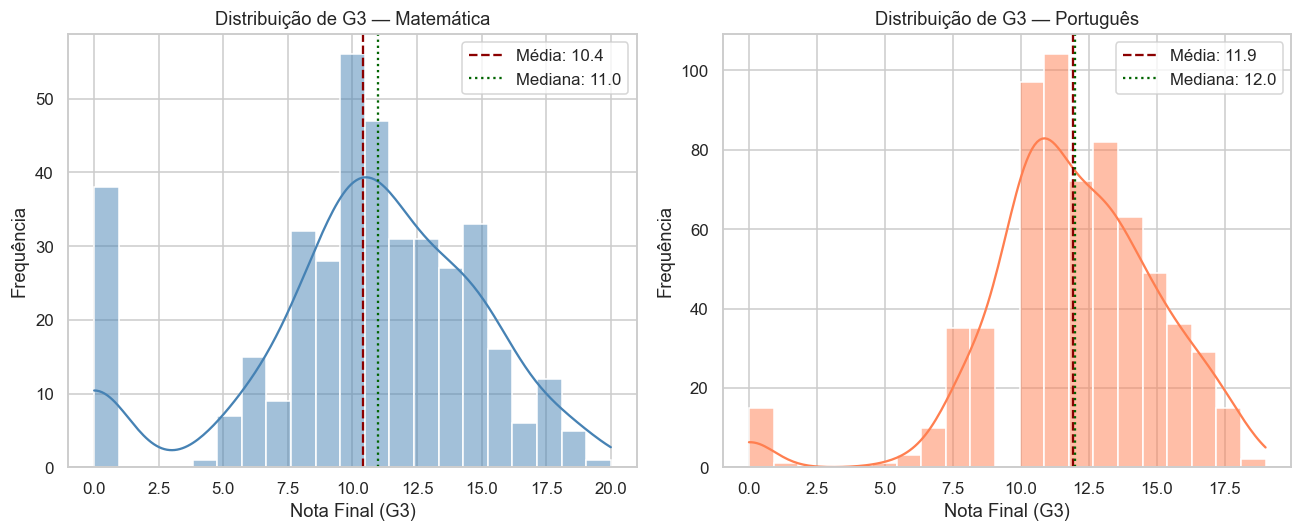

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, nome, cor in zip(axes, [mat, por], ['Matemática', 'Português'], ['steelblue', 'coral']):
    sns.histplot(df['G3'], kde=True, bins=21, ax=ax, color=cor)
    ax.axvline(df['G3'].mean(), color='darkred', linestyle='--', label=f'Média: {df["G3"].mean():.1f}')
    ax.axvline(df['G3'].median(), color='darkgreen', linestyle=':', label=f'Mediana: {df["G3"].median():.1f}')
    ax.set_title(f'Distribuição de G3 — {nome}')
    ax.set_xlabel('Nota Final (G3)')
    ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig('plot_p1_distribuicao_g3.png', bbox_inches='tight')
plt.show()

**Achado:** A distribuição de G3 em Matemática apresenta um pico acentuado em zero (38 alunos — possíveis
desistentes ou ausentes na avaliação final), enquanto Português tem distribuição mais próxima da normal,
com concentração entre 10 e 15. Isso indica maior taxa de evasão/desistência em Matemática. A média em
Português (≈11.9) é consistentemente mais alta do que em Matemática (≈10.4).

---
### Pergunta 2 — Estudantes que desejam cursar o ensino superior têm notas melhores?

**Justificativa do gráfico:** O boxplot é ideal para comparar distribuições entre dois grupos, pois mostra
mediana, quartis e outliers de forma compacta. É superior à simples comparação de médias por evidenciar a
variabilidade e a presença de valores extremos.

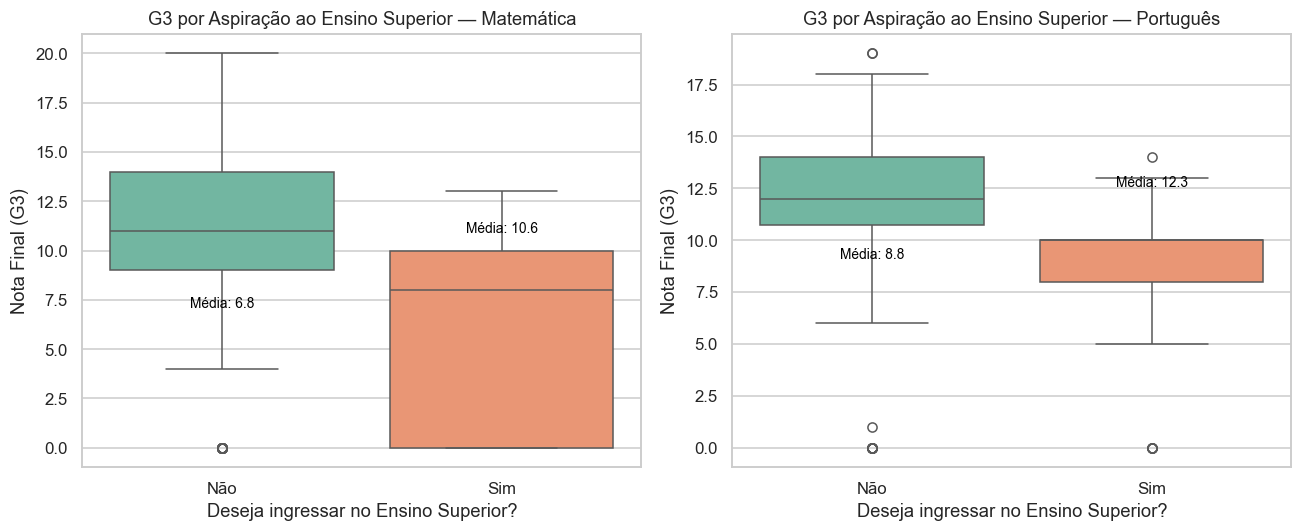

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, nome in zip(axes, [mat, por], ['Matemática', 'Português']):
    sns.boxplot(data=df, x='higher', y='G3', ax=ax, palette='Set2')
    medias = df.groupby('higher')['G3'].mean()
    for i, (grp, media) in enumerate(medias.items()):
        ax.text(i, media + 0.3, f'Média: {media:.1f}', ha='center', fontsize=9, color='black')
    ax.set_title(f'G3 por Aspiração ao Ensino Superior — {nome}')
    ax.set_xlabel('Deseja ingressar no Ensino Superior?')
    ax.set_ylabel('Nota Final (G3)')
    ax.set_xticklabels(['Não', 'Sim'])

plt.tight_layout()
plt.savefig('plot_p2_ensino_superior.png', bbox_inches='tight')
plt.show()

**Achado:** Em ambas as disciplinas, estudantes que desejam ingressar no ensino superior apresentam notas
finais consideravelmente maiores. A diferença de médias é de aproximadamente 3–4 pontos em Matemática e
2–3 em Português. Além das médias, o boxplot revela que a distribuição do grupo "Sim" tem dispersão menor —
indicando maior consistência no desempenho.

---
### Pergunta 3 — O tempo de estudo semanal está associado a notas mais altas?

**Justificativa do gráfico:** O gráfico de barras com intervalo de confiança permite comparar a média de G3
por categoria ordinal (tempo de estudo), tornando visível a tendência crescente ou não entre grupos.
As barras de erro informam a confiabilidade da estimativa de cada grupo.

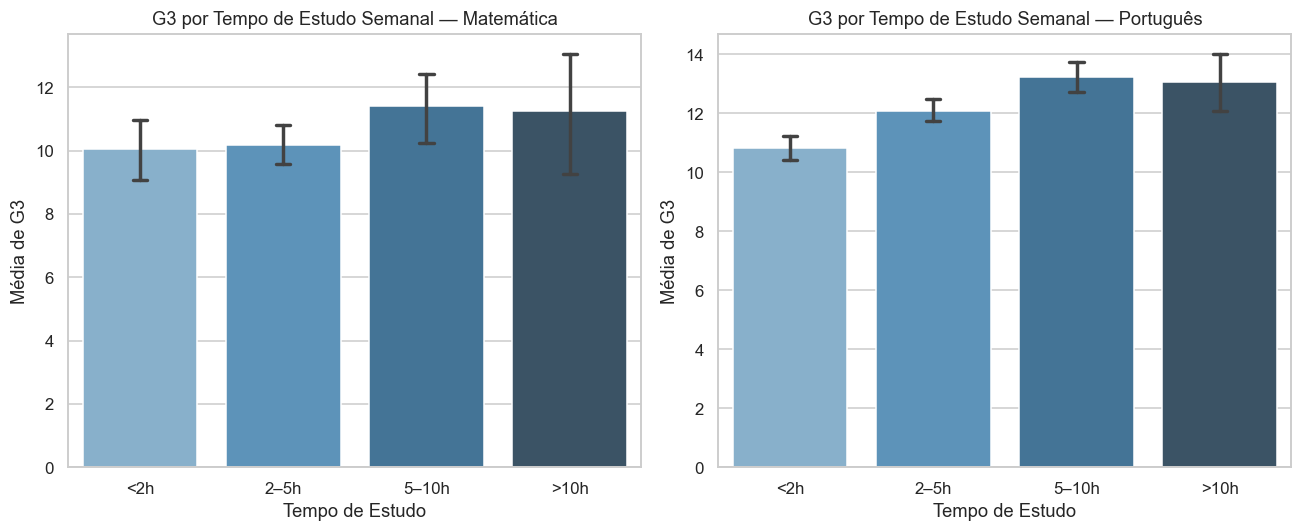

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels_st = {1: '<2h', 2: '2–5h', 3: '5–10h', 4: '>10h'}

for ax, df, nome in zip(axes, [mat, por], ['Matemática', 'Português']):
    df_plot = df.copy()
    df_plot['studytime_label'] = df_plot['studytime'].map(labels_st)
    order = ['<2h', '2–5h', '5–10h', '>10h']
    sns.barplot(data=df_plot, x='studytime_label', y='G3', order=order, ax=ax,
                palette='Blues_d', errorbar='ci', capsize=0.1)
    ax.set_title(f'G3 por Tempo de Estudo Semanal — {nome}')
    ax.set_xlabel('Tempo de Estudo')
    ax.set_ylabel('Média de G3')

plt.tight_layout()
plt.savefig('plot_p3_studytime.png', bbox_inches='tight')
plt.show()

**Achado:** Há uma tendência positiva entre tempo de estudo e nota final, especialmente visível em
Matemática. Contudo, o grupo ">10h" nem sempre apresenta as notas mais altas, possivelmente porque
estudantes com dificuldades compensam estudando mais (causalidade reversa). O intervalo de confiança
para ">10h" é largo, indicando menor número de observações nesse grupo.

---
### Pergunta 4 — O consumo de álcool afeta o desempenho escolar? (relação entre variáveis)

**Justificativa do gráfico:** O heatmap de correlação apresenta de forma compacta a intensidade e direção
das relações entre múltiplas variáveis numéricas simultaneamente. É especialmente útil para identificar
quais variáveis comportamentais se correlacionam com as notas.

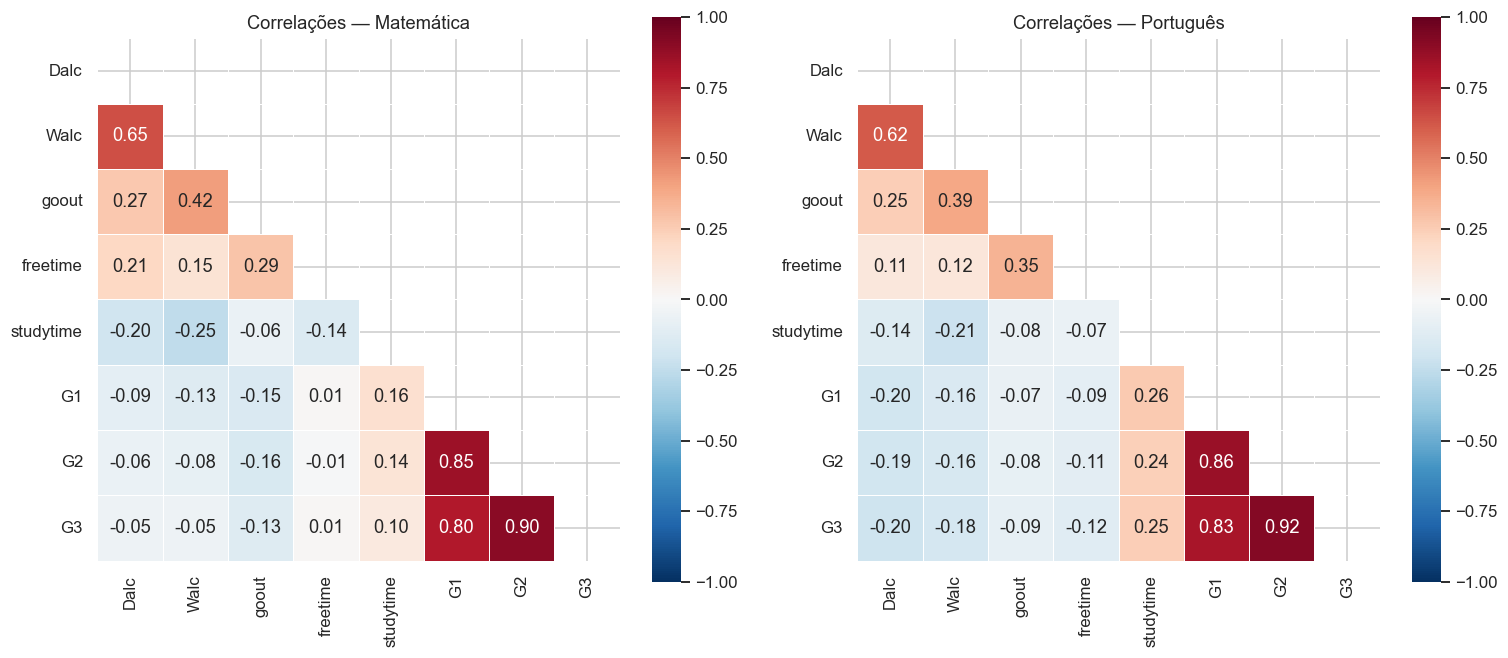

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vars_interesse = ['Dalc', 'Walc', 'goout', 'freetime', 'studytime', 'G1', 'G2', 'G3']

for ax, df, nome in zip(axes, [mat, por], ['Matemática', 'Português']):
    corr = df[vars_interesse].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5)
    ax.set_title(f'Correlações — {nome}')

plt.tight_layout()
plt.savefig('plot_p4_correlacao_alcool.png', bbox_inches='tight')
plt.show()

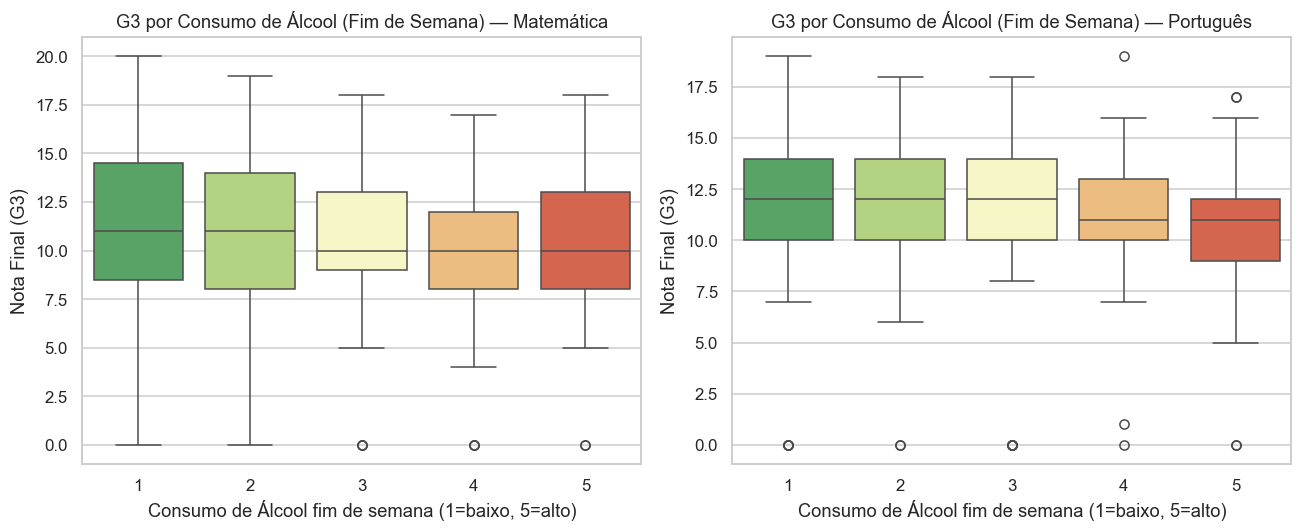

In [32]:
# Boxplot direto: G3 por nível de consumo de álcool nos fins de semana
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, nome in zip(axes, [mat, por], ['Matemática', 'Português']):
    sns.boxplot(data=df, x='Walc', y='G3', ax=ax, palette='RdYlGn_r')
    ax.set_title(f'G3 por Consumo de Álcool (Fim de Semana) — {nome}')
    ax.set_xlabel('Consumo de Álcool fim de semana (1=baixo, 5=alto)')
    ax.set_ylabel('Nota Final (G3)')

plt.tight_layout()
plt.savefig('plot_p4b_alcool_boxplot.png', bbox_inches='tight')
plt.show()

**Achado:** Há correlação negativa entre consumo de álcool (Dalc e Walc) e a nota final (G3), mais
pronunciada em Matemática (r ≈ −0.22 para Walc). O consumo de álcool também se correlaciona positivamente
com o hábito de sair com amigos (goout), sugerindo que faz parte de um padrão comportamental mais amplo.
O boxplot confirma: medianas de G3 decrescem conforme o nível de consumo aumenta.

---
### Pergunta 5 — A escolaridade dos pais influencia as notas dos filhos? (relação entre variáveis)

**Justificativa do gráfico:** O gráfico de dispersão (scatter) com linha de tendência é adequado para
visualizar a relação entre duas variáveis contínuas/ordinais, especialmente quando se deseja avaliar a
direção e força da associação.

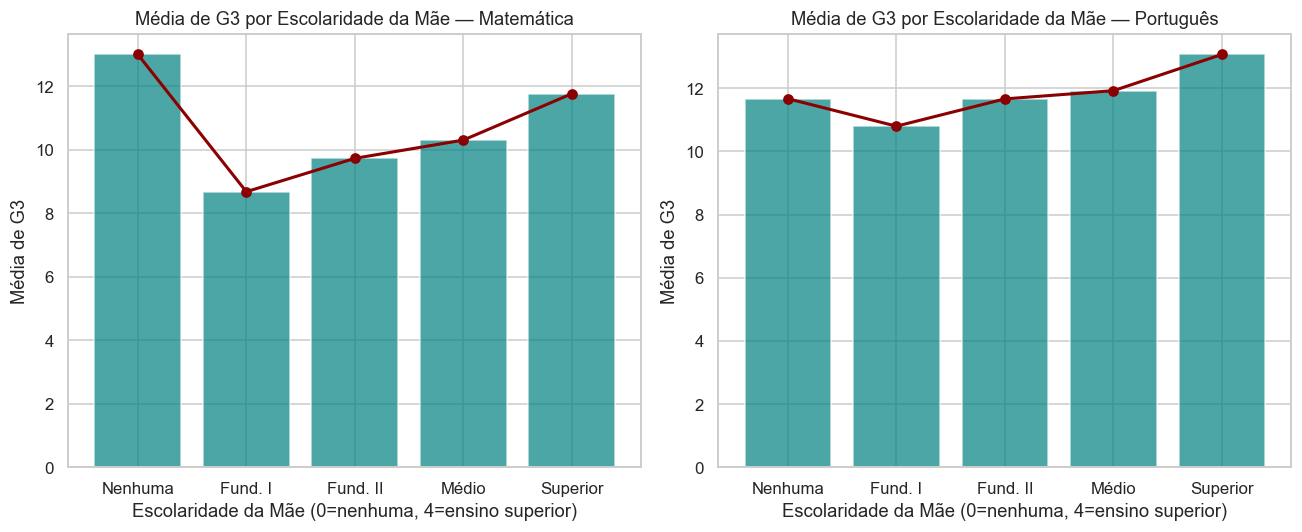

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, nome in zip(axes, [mat, por], ['Matemática', 'Português']):
    medias = df.groupby('Medu')['G3'].mean().reset_index()
    ax.bar(medias['Medu'], medias['G3'], color='teal', alpha=0.7)
    ax.plot(medias['Medu'], medias['G3'], 'o-', color='darkred', linewidth=2)
    ax.set_title(f'Média de G3 por Escolaridade da Mãe — {nome}')
    ax.set_xlabel('Escolaridade da Mãe (0=nenhuma, 4=ensino superior)')
    ax.set_ylabel('Média de G3')
    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels(['Nenhuma', 'Fund. I', 'Fund. II', 'Médio', 'Superior'])

plt.tight_layout()
plt.savefig('plot_p5_escolaridade_pais.png', bbox_inches='tight')
plt.show()

**Achado:** Há uma tendência clara: quanto maior a escolaridade dos pais (especialmente da mãe), maiores
as notas dos filhos. Isso é consistente com a literatura em Sociologia da Educação, que aponta o capital
cultural familiar como um dos mais fortes determinantes do desempenho escolar. A tendência é observada em
ambas as disciplinas.

---
### Pergunta 6 — Há diferença de desempenho entre estudantes do sexo feminino e masculino? (relação entre variáveis)

**Justificativa do gráfico:** O violin plot combina o boxplot com a distribuição de densidade, permitindo
ver não apenas os resumos estatísticos (mediana, quartis) mas também a forma completa da distribuição
por grupo.

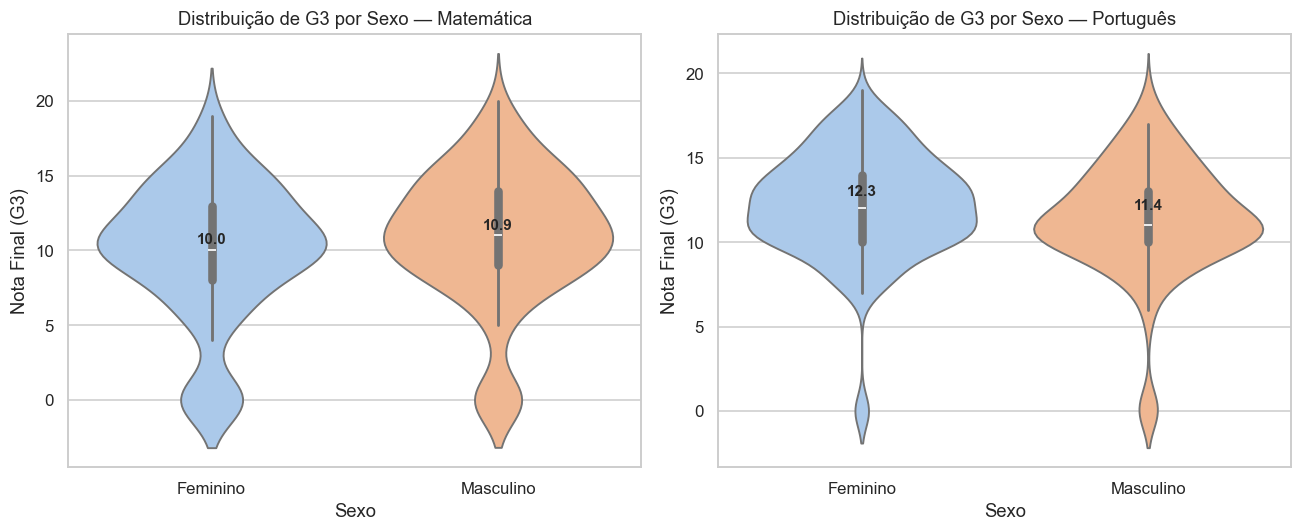

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, nome in zip(axes, [mat, por], ['Matemática', 'Português']):
    sns.violinplot(data=df, x='sex', y='G3', ax=ax, palette='pastel', inner='box')
    medias = df.groupby('sex')['G3'].mean()
    for i, (grp, media) in enumerate(medias.items()):
        ax.text(i, media + 0.5, f'{media:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Distribuição de G3 por Sexo — {nome}')
    ax.set_xlabel('Sexo')
    ax.set_ylabel('Nota Final (G3)')
    ax.set_xticklabels(['Feminino', 'Masculino'])

plt.tight_layout()
plt.savefig('plot_p6_sexo.png', bbox_inches='tight')
plt.show()

**Achado:** Em Matemática, estudantes do sexo masculino tendem a ter médias ligeiramente mais altas,
enquanto em Português a diferença é pequena ou invertida (feminino com média levemente superior). As
diferenças são moderadas e consistentes com padrões reportados na literatura — não configuram discriminação
estrutural, mas refletem diferenças nas escolhas e percepções sobre as disciplinas.

---
### Pergunta 7 — O número de reprovações anteriores está correlacionado com a nota final?

**Justificativa do gráfico:** Barras horizontais com médias são adequadas para comparar poucos grupos
categóricos (0, 1, 2, 3 reprovações), facilitando a leitura quando os rótulos são longos. A tendência
decrescente é mais fácil de perceber visualmente.

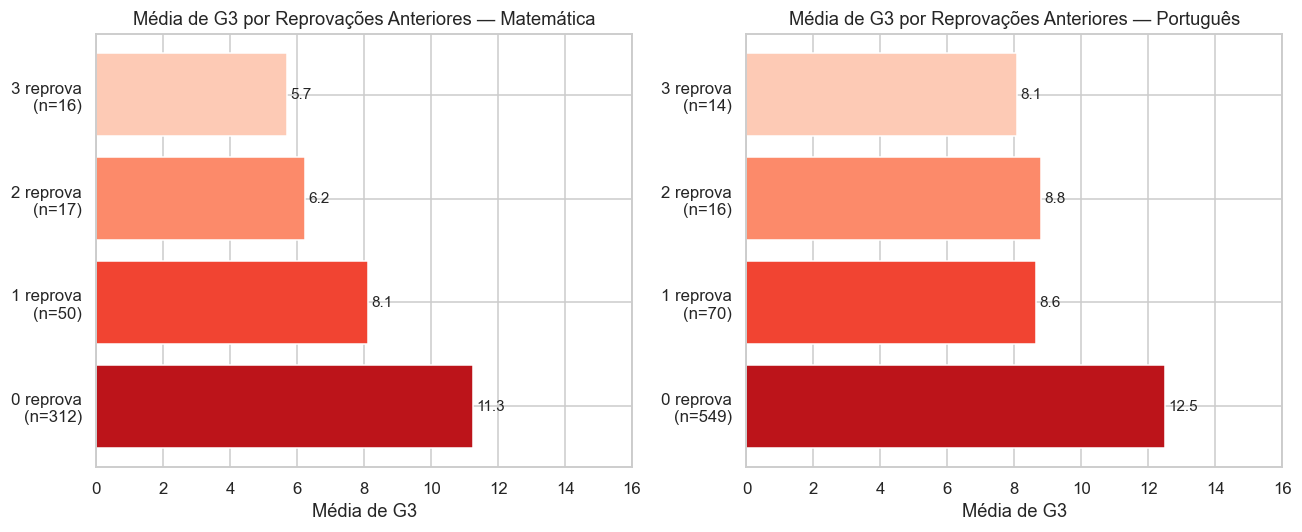

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, nome in zip(axes, [mat, por], ['Matemática', 'Português']):
    medias = df.groupby('failures')['G3'].mean().reset_index()
    counts = df.groupby('failures').size().reset_index(name='n')
    medias = medias.merge(counts, on='failures')
    labels = [f'{int(f)} reprova\n(n={n})' for f, n in zip(medias['failures'], medias['n'])]
    bars = ax.barh(labels, medias['G3'], color=sns.color_palette('Reds_r', len(medias)))
    for bar, val in zip(bars, medias['G3']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=10)
    ax.set_title(f'Média de G3 por Reprovações Anteriores — {nome}')
    ax.set_xlabel('Média de G3')
    ax.set_xlim(0, 16)

plt.tight_layout()
plt.savefig('plot_p7_reprovacoes.png', bbox_inches='tight')
plt.show()

**Achado:** Há uma relação negativa clara e consistente entre número de reprovações anteriores e nota final.
Estudantes sem reprovações têm médias de G3 consideravelmente mais altas (≈11–12) do que os que reprovaram
3 ou mais vezes (≈5–7). O número de reprovações é, portanto, um forte sinal de risco acadêmico.

---
### Pergunta 8 — Estudantes com mais faltas tendem a ter notas finais mais baixas?

**Justificativa do gráfico:** O gráfico de dispersão (scatter plot) é o mais adequado para explorar a
relação entre duas variáveis contínuas, como absences e G3, revelando se há tendência linear, não-linear
ou ausência de padrão.

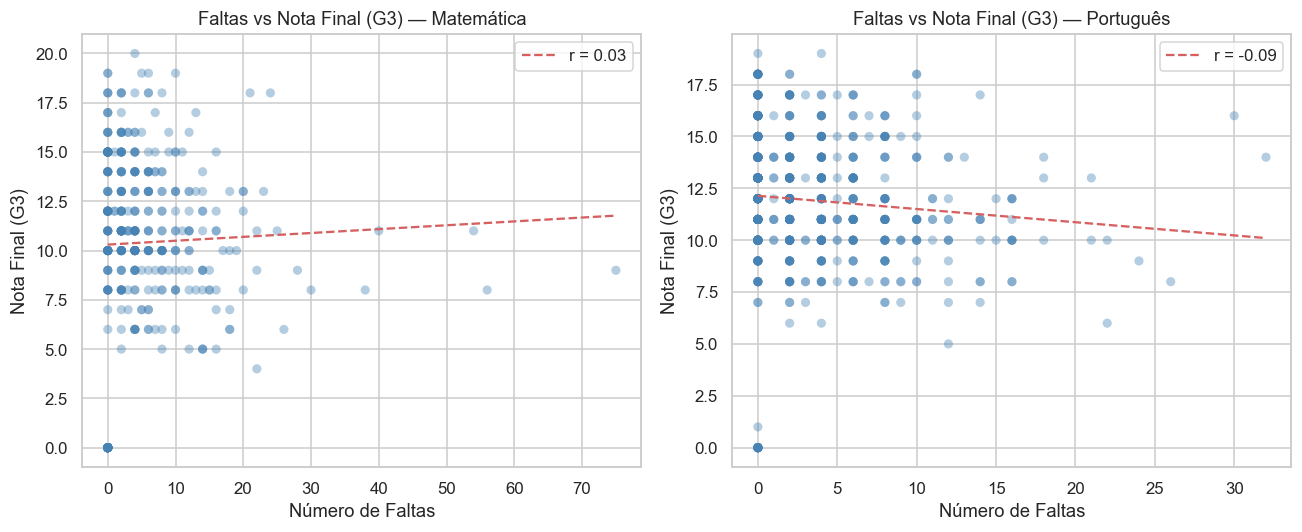

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, nome in zip(axes, [mat, por], ['Matemática', 'Português']):
    ax.scatter(df['absences'], df['G3'], alpha=0.4, color='steelblue', edgecolors='none')
    z = np.polyfit(df['absences'], df['G3'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df['absences'].min(), df['absences'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label=f'r = {df["absences"].corr(df["G3"]):.2f}')
    ax.set_title(f'Faltas vs Nota Final (G3) — {nome}')
    ax.set_xlabel('Número de Faltas')
    ax.set_ylabel('Nota Final (G3)')
    ax.legend()

plt.tight_layout()
plt.savefig('plot_p8_faltas.png', bbox_inches='tight')
plt.show()

**Achado:** A correlação entre faltas e G3 é negativa, porém relativamente fraca (r ≈ −0.03 a −0.09).
O scatter plot revela grande dispersão: existem alunos com muitas faltas e notas altas, e vice-versa.
Faltas, portanto, não são um preditor isolado confiável do desempenho — outros fatores são mais
determinantes.

---
### Pergunta 9 — Existe uma progressão consistente entre G1, G2 e G3 ao longo do ano?

**Justificativa do gráfico:** O scatter plot entre G1/G2 e G3 permite avaliar o quanto as notas anteriores
predizem a nota final. Uma nuvem de pontos próxima à diagonal y=x indicaria predição perfeita, enquanto
dispersão ao redor dela indica variação real.

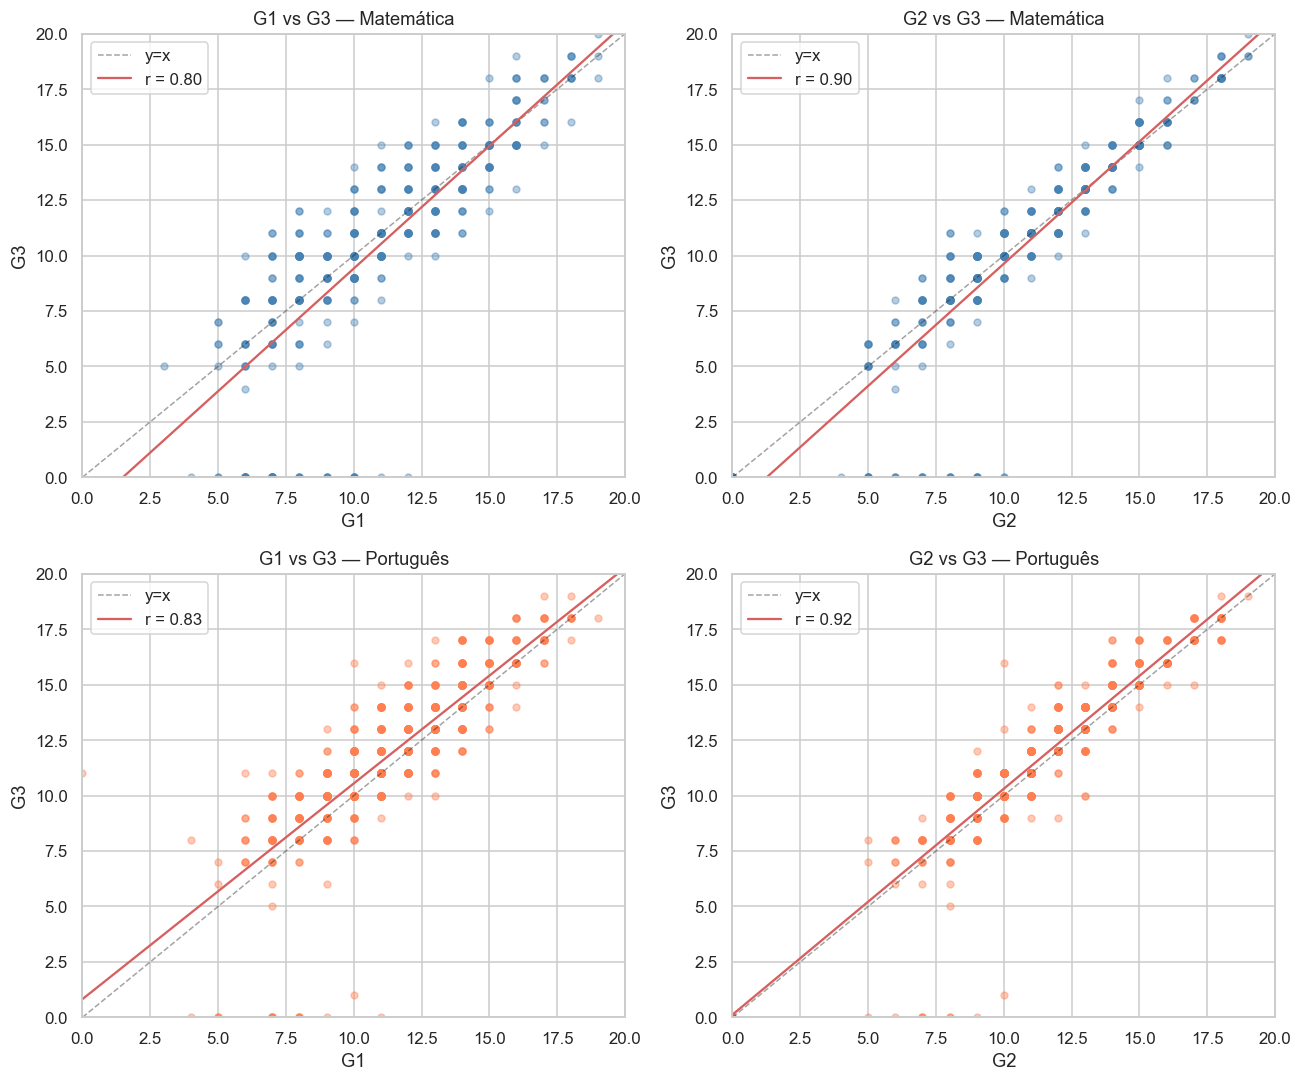

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

pairs = [('G1', 'G3'), ('G2', 'G3')]
for row, (df, nome) in enumerate([(mat, 'Matemática'), (por, 'Português')]):
    for col, (gx, gy) in enumerate(pairs):
        ax = axes[row][col]
        r = df[gx].corr(df[gy])
        ax.scatter(df[gx], df[gy], alpha=0.4, color='steelblue' if nome=='Matemática' else 'coral', s=20)
        lims = [0, 20]
        ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1, label='y=x')
        z = np.polyfit(df[gx], df[gy], 1)
        p = np.poly1d(z)
        ax.plot(lims, p(lims), 'r-', linewidth=1.5, label=f'r = {r:.2f}')
        ax.set_title(f'{gx} vs {gy} — {nome}')
        ax.set_xlabel(gx); ax.set_ylabel(gy)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.legend()

plt.tight_layout()
plt.savefig('plot_p9_progressao.png', bbox_inches='tight')
plt.show()

**Achado:** G1 e G2 são fortes preditores de G3, com correlações em torno de 0.80–0.92. A dispersão ao
redor da diagonal y=x mostra que há variação (alguns alunos melhoram, outros pioram), mas a maioria mantém
trajetória consistente. G2 prediz G3 melhor do que G1, o que faz sentido: está mais próximo da avaliação
final. Isso tem implicação direta para a modelagem: G1 e G2 serão as features mais poderosas.

---
### Pergunta 10 — O tipo de endereço (urbano vs. rural) influencia o desempenho?

**Justificativa do gráfico:** Um gráfico de barras agrupadas com médias permite comparar diretamente os
grupos (urbano/rural) em diferentes momentos do ano (G1, G2, G3), revelando se a diferença é consistente
ao longo do tempo.

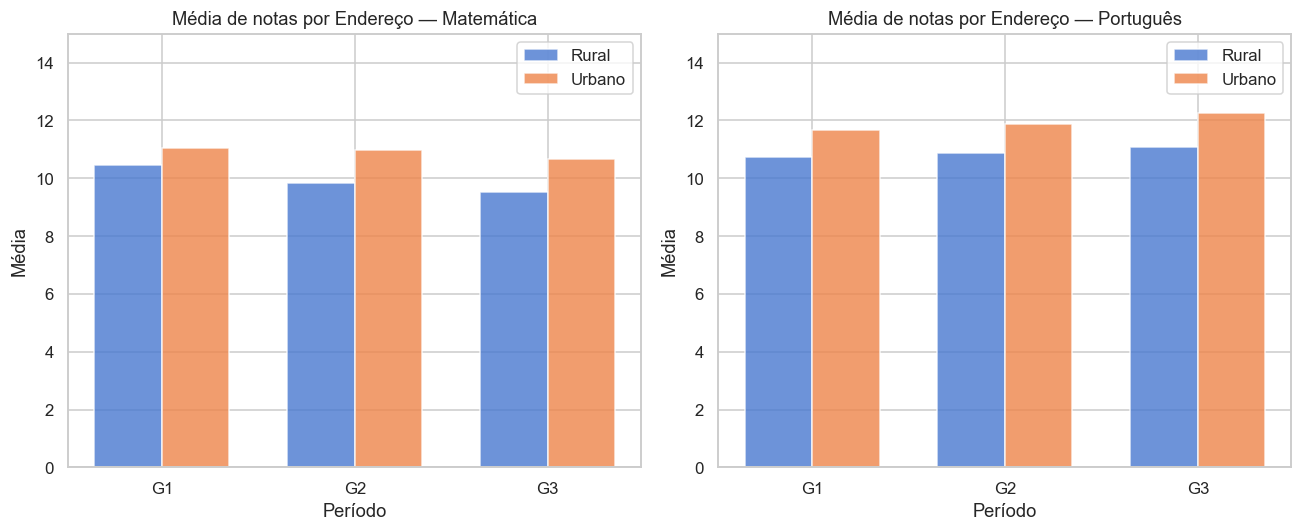

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, nome in zip(axes, [mat, por], ['Matemática', 'Português']):
    data = df.groupby('address')[['G1','G2','G3']].mean().reset_index()
    data['address'] = data['address'].map({'U': 'Urbano', 'R': 'Rural'})
    x = np.arange(3)
    width = 0.35
    for i, (_, row) in enumerate(data.iterrows()):
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, [row['G1'], row['G2'], row['G3']], width, label=row['address'],
                     alpha=0.8)
    ax.set_title(f'Média de notas por Endereço — {nome}')
    ax.set_xlabel('Período')
    ax.set_ylabel('Média')
    ax.set_xticks(x)
    ax.set_xticklabels(['G1', 'G2', 'G3'])
    ax.legend()
    ax.set_ylim(0, 15)

plt.tight_layout()
plt.savefig('plot_p10_endereco.png', bbox_inches='tight')
plt.show()

**Achado:** Estudantes urbanos tendem a ter médias de notas levemente superiores em ambas as disciplinas.
A diferença não é dramática, mas é consistente ao longo dos três períodos (G1, G2, G3). Fatores como
acesso a internet, distância da escola e recursos de apoio podem explicar essa diferença.

---
## 6. Síntese Crítica dos Principais Achados

A análise exploratória revelou um conjunto rico de insights sobre os fatores associados ao desempenho
escolar dos estudantes:

**Variáveis com maior associação com G3:**
- **G1 e G2** são os preditores mais fortes da nota final (r ≈ 0.80–0.92), indicando que a trajetória
  escolar ao longo do ano é altamente consistente.
- **Reprovações anteriores** (`failures`) apresentam correlação negativa relevante (r ≈ −0.35–0.40):
  histórico de dificuldades acadêmicas é um sinal de alerta robusto.
- **Aspiração ao ensino superior** (`higher`) está associada a notas sistematicamente mais altas,
  refletindo motivação ou seleção acadêmica.
- **Escolaridade dos pais** (especialmente da mãe) mostra tendência positiva, alinhada à literatura
  sobre capital cultural familiar.

**Variáveis comportamentais:**
- **Consumo de álcool** tem efeito negativo moderado, sendo parte de um padrão comportamental mais
  amplo (saídas com amigos, menos estudo).
- **Tempo de estudo** mostra tendência positiva, mas com ruído — possivelmente porque estudantes com
  dificuldades compensam estudando mais (causalidade reversa).

**Variáveis com efeito pequeno ou incerto:**
- **Faltas** (`absences`) têm correlação fraca com G3, com alta dispersão.
- **Sexo** e **endereço** apresentam diferenças pequenas, mas coerentes com padrões conhecidos.

**Limitações observadas:**
- O dataset é relativamente pequeno (357–634 registros após remoção de zeros), o que pode limitar a
  generalização de modelos preditivos.
- A presença de notas zero em G3 exige tratamento antes da modelagem (tratamos como desistência).
- O dataset é de duas escolas específicas de Portugal em 2005–2006, limitando a aplicabilidade a outros
  contextos educacionais.

**Direções para a Parte 2 (Modelagem):**
- **Variável-alvo:** G3 (regressão contínua)
- **Features mais promissoras:** G1, G2, failures, higher, Medu, studytime, Dalc/Walc
- Será importante avaliar o impacto de incluir/excluir G1/G2 como features (cenário realista vs.
  cenário teórico)

---
# PARTE 2 — Modelagem e Avaliação (ML)
---

## 7. Definição do Objetivo Preditivo

### Tarefa: Regressão

O objetivo desta parte é **prever a nota final G3** dos estudantes com base em suas características
demográficas, comportamentais e históricas de desempenho.

**Variável-alvo:** `G3` (nota final, escala 1–20, após remoção dos zeros que representam desistências)

**Por que G3?** G3 é a nota final que determina a aprovação ou reprovação do aluno. Predizê-la com
antecedência — com base em G1, G2 e características pessoais — permitiria que professores identificassem
alunos em risco e interviessem antes do final do ano letivo.

**Por que regressão e não classificação?** A nota G3 é uma variável contínua ordinal (1–20). Manter como
regressão preserva toda a informação; uma classificação binária (aprovado/reprovado) perderia gradações
importantes. Além disso, o RMSE em escala de notas é mais interpretável para um educador.

**Cenário adotado:** Treinaremos os modelos **com G1 e G2** como features, que é o cenário mais realista
(o professor já tem as notas dos bimestres anteriores ao fazer a predição). Discutiremos as limitações
dessa escolha.

## 8. Importações Adicionais para Modelagem

In [39]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

print('Bibliotecas de ML carregadas com sucesso.')

Bibliotecas de ML carregadas com sucesso.


## 9. Preparação dos Dados para Modelagem

### 9.1 Remoção dos zeros em G3

Estudantes com G3=0 representam desistências/ausências, não baixo desempenho real. Incluí-los distorceria
os modelos preditivos (o modelo tentaria aprender a prever zeros a partir de características que não
distinguem desistentes).

In [40]:
# Remoção dos registros com G3=0
mat_ml = mat[mat['G3'] > 0].copy()
por_ml = por[por['G3'] > 0].copy()

print(f'Matemática: {len(mat)} → {len(mat_ml)} registros (removidos {len(mat)-len(mat_ml)} zeros)')
print(f'Português:  {len(por)} → {len(por_ml)} registros (removidos {len(por)-len(por_ml)} zeros)')

Matemática: 395 → 357 registros (removidos 38 zeros)
Português:  649 → 634 registros (removidos 15 zeros)


### 9.2 Encoding das variáveis categóricas

As variáveis categóricas (sexo, endereço, escola, etc.) precisam ser convertidas em numéricas para os
algoritmos de ML. Usamos **One-Hot Encoding** com `drop_first=True` para evitar multicolinearidade
(armadilha das variáveis dummy).

**Cuidado com data leakage:** O encoding é aplicado nos dados completos antes da divisão treino/teste
apenas para este dataset estático. Em produção, o encoder seria ajustado apenas no treino.

In [41]:
CAT_COLS = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian',
            'schoolsup', 'famsup', 'paid', 'activities',
            'nursery', 'higher', 'internet', 'romantic']

def encode_dataset(df, target='G3'):
    """Aplica One-Hot Encoding e retorna X, y."""
    d = pd.get_dummies(df, columns=CAT_COLS, drop_first=True)
    X = d.drop(columns=[target])
    y = d[target]
    return X, y

X_mat, y_mat = encode_dataset(mat_ml)
X_por, y_por = encode_dataset(por_ml)

print(f'Features Matemática: {X_mat.shape[1]}')
print(f'Features Português:  {X_por.shape[1]}')
print(f'\nExemplo de features:\n{list(X_mat.columns[:10])} ...')

Features Matemática: 41
Features Português:  41

Exemplo de features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc'] ...


### 9.3 Divisão Treino/Teste

A divisão é feita **antes** de qualquer transformação de escala (normalização), para evitar data leakage.
O StandardScaler é ajustado **apenas nos dados de treino** e aplicado nos dados de teste.

In [42]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Matemática
X_mat_tr, X_mat_te, y_mat_tr, y_mat_te = train_test_split(
    X_mat, y_mat, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Português
X_por_tr, X_por_te, y_por_tr, y_por_te = train_test_split(
    X_por, y_por, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print('=== Tamanhos dos conjuntos ===')
print(f'Matemática — Treino: {len(X_mat_tr)} | Teste: {len(X_mat_te)}')
print(f'Português  — Treino: {len(X_por_tr)} | Teste: {len(X_por_te)}')

=== Tamanhos dos conjuntos ===
Matemática — Treino: 285 | Teste: 72
Português  — Treino: 507 | Teste: 127


In [43]:
# Normalização (ajuste APENAS no treino, transformação em ambos)
# Necessária para modelos sensíveis a escala (Ridge) — mantemos para todos por consistência

scaler_mat = StandardScaler()
X_mat_tr_s = scaler_mat.fit_transform(X_mat_tr)  # fit + transform no treino
X_mat_te_s = scaler_mat.transform(X_mat_te)       # apenas transform no teste

scaler_por = StandardScaler()
X_por_tr_s = scaler_por.fit_transform(X_por_tr)
X_por_te_s = scaler_por.transform(X_por_te)

print('Normalização aplicada. Scaler ajustado apenas no conjunto de treino.')
print(f'Média das features de treino (Mat) após scaling ≈ {X_mat_tr_s.mean():.4f}')
print(f'Std das features de treino (Mat) após scaling ≈ {X_mat_tr_s.std():.4f}')

Normalização aplicada. Scaler ajustado apenas no conjunto de treino.
Média das features de treino (Mat) após scaling ≈ -0.0000
Std das features de treino (Mat) após scaling ≈ 1.0000


### 9.4 Métricas escolhidas

Para um problema de regressão no contexto educacional, usaremos:

| Métrica | Fórmula | Interpretação |
|---|---|---|
| **RMSE** | √MSE | Erro médio em unidades de nota (0–20). Penaliza erros grandes. |
| **MAE** | Média(|y - ŷ|) | Erro absoluto médio. Mais robusto a outliers. |
| **R²** | 1 - SS_res/SS_tot | Proporção da variância explicada pelo modelo (0–1). |
| **CV-R²** | R² médio em 5-fold CV | Estimativa robusta da generalização no conjunto de treino. |

## 10. Modelos de ML

### Modelos selecionados e justificativas

1. **Regressão Linear (Baseline):** Modelo mais simples possível. Assume relação linear entre features e
   alvo. Serve como referência — qualquer modelo mais complexo deve superá-lo para justificar sua
   complexidade.

2. **Árvore de Decisão:** Modelo não-linear, interpretável, captura interações entre variáveis. Tende a
   overfitting sem regularização — por isso serve como contraste ao Random Forest.

3. **Random Forest:** Ensemble de árvores com bagging. Reduz o overfitting da árvore individual e lida
   bem com muitas features. Esperamos que seja o melhor modelo dado o tamanho moderado do dataset.

4. **Gradient Boosting:** Ensemble sequencial que corrige os erros dos modelos anteriores. Pode superar
   o Random Forest com tuning adequado, mas é mais lento e sensível a hiperparâmetros.

In [44]:
def avaliar_modelo(model, X_tr, y_tr, X_te, y_te, nome):
    """Treina, avalia e retorna métricas de um modelo."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    
    return {'Modelo': nome, 'RMSE': round(rmse,3), 'MAE': round(mae,3),
            'R²': round(r2,3), 'CV-R²': round(cv,3)}

modelos = [
    ('Regressão Linear (Baseline)', LinearRegression()),
    ('Árvore de Decisão',           DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ('Random Forest',               RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)),
    ('Gradient Boosting',           GradientBoostingRegressor(random_state=RANDOM_STATE)),
]

print('Treinando modelos...')

# Matemática
resultados_mat = []
modelos_treinados_mat = {}
for nome, model in modelos:
    res = avaliar_modelo(model, X_mat_tr_s, y_mat_tr, X_mat_te_s, y_mat_te, nome)
    resultados_mat.append(res)
    modelos_treinados_mat[nome] = model

# Português
resultados_por = []
modelos_treinados_por = {}
for nome, model in modelos:
    res = avaliar_modelo(model, X_por_tr_s, y_por_tr, X_por_te_s, y_por_te, nome)
    resultados_por.append(res)
    modelos_treinados_por[nome] = model

df_mat = pd.DataFrame(resultados_mat).sort_values('R²', ascending=False)
df_por = pd.DataFrame(resultados_por).sort_values('R²', ascending=False)

print('\n=== Resultados — Matemática ===')
print(df_mat.to_string(index=False))
print('\n=== Resultados — Português ===')
print(df_por.to_string(index=False))

Treinando modelos...

=== Resultados — Matemática ===
                     Modelo  RMSE   MAE    R²  CV-R²
              Random Forest 0.821 0.599 0.930  0.915
Regressão Linear (Baseline) 0.900 0.675 0.916  0.923
          Gradient Boosting 0.910 0.679 0.914  0.919
          Árvore de Decisão 1.124 0.847 0.869  0.853

=== Resultados — Português ===
                     Modelo  RMSE   MAE    R²  CV-R²
Regressão Linear (Baseline) 0.945 0.765 0.891  0.870
          Gradient Boosting 1.010 0.766 0.876  0.861
              Random Forest 1.025 0.766 0.872  0.869
          Árvore de Decisão 1.950 1.205 0.536  0.764


## 11. Comparação Visual dos Modelos

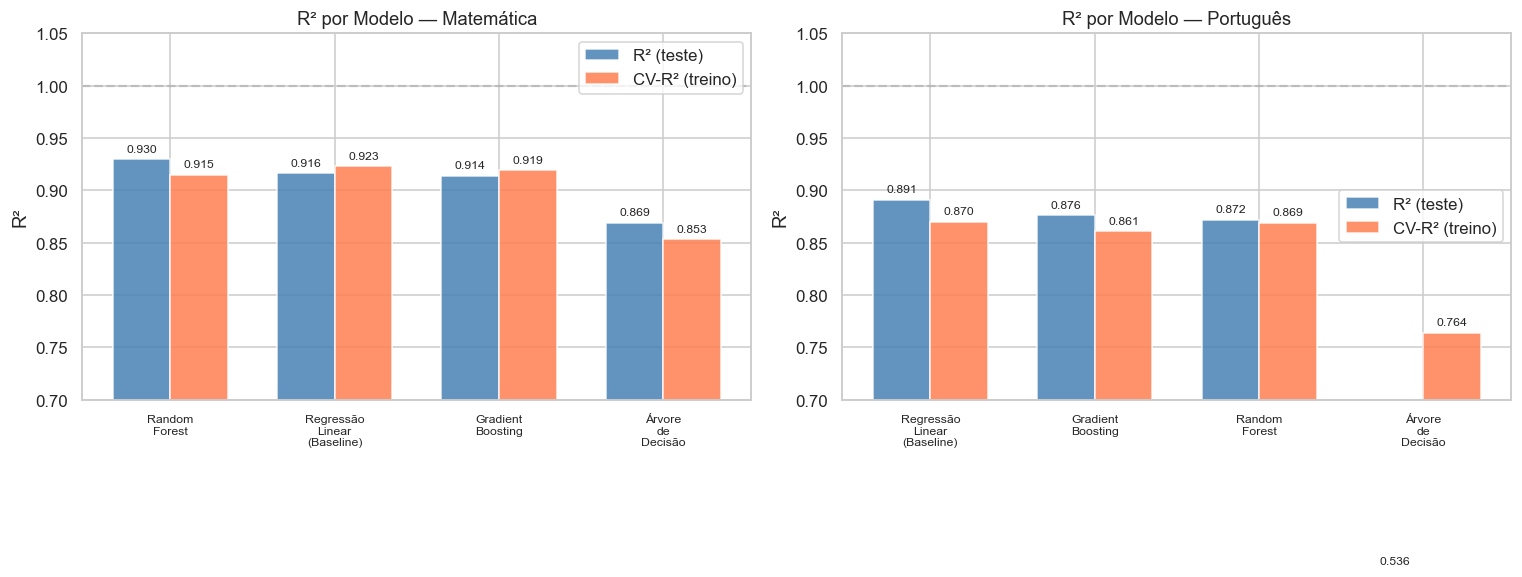

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_res, nome in zip(axes, [df_mat, df_por], ['Matemática', 'Português']):
    x = np.arange(len(df_res))
    width = 0.35
    bars1 = ax.bar(x - width/2, df_res['R²'], width, label='R² (teste)', color='steelblue', alpha=0.85)
    bars2 = ax.bar(x + width/2, df_res['CV-R²'], width, label='CV-R² (treino)', color='coral', alpha=0.85)
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_title(f'R² por Modelo — {nome}')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ', '\n') for m in df_res['Modelo']], fontsize=8)
    ax.set_ylabel('R²')
    ax.set_ylim(0.7, 1.05)
    ax.legend()
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_p11_comparacao_modelos.png', bbox_inches='tight')
plt.show()

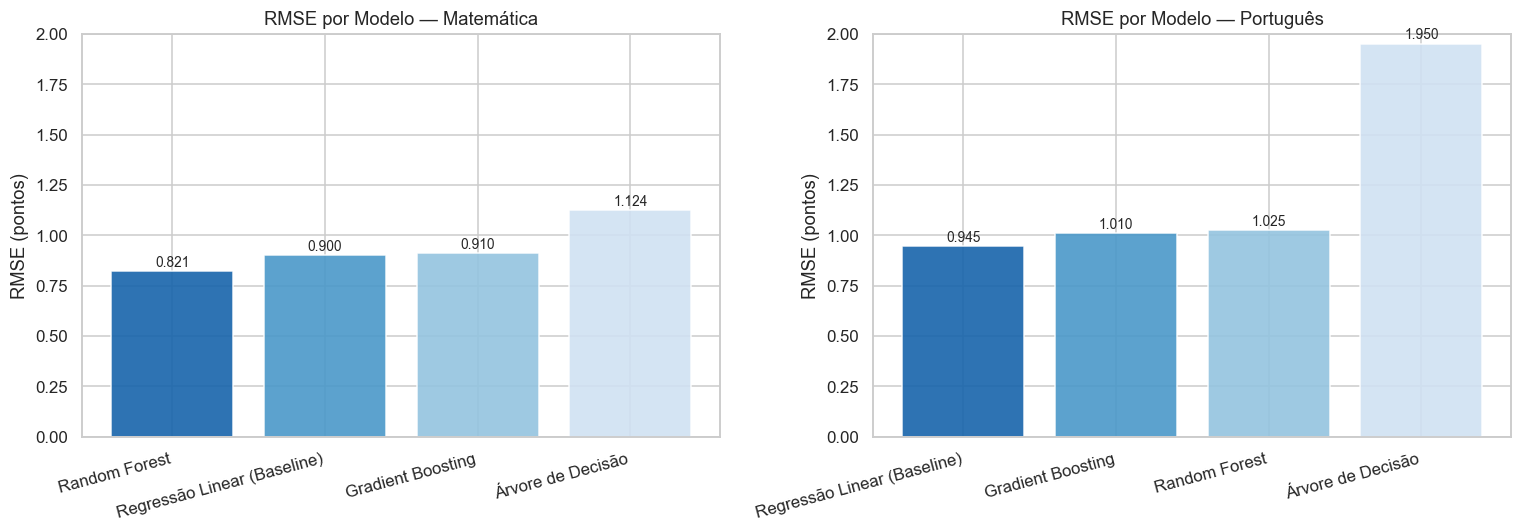

In [46]:
# Comparação por RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_res, nome in zip(axes, [df_mat, df_por], ['Matemática', 'Português']):
    bars = ax.bar(df_res['Modelo'], df_res['RMSE'],
                  color=sns.color_palette('Blues_r', len(df_res)), alpha=0.9)
    for bar, val in zip(bars, df_res['RMSE']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'RMSE por Modelo — {nome}')
    ax.set_ylabel('RMSE (pontos)')
    ax.set_xticklabels(df_res['Modelo'], rotation=15, ha='right')
    ax.set_ylim(0, 2.0)

plt.tight_layout()
plt.savefig('plot_p11b_rmse.png', bbox_inches='tight')
plt.show()

## 12. Importância das Features (Random Forest)

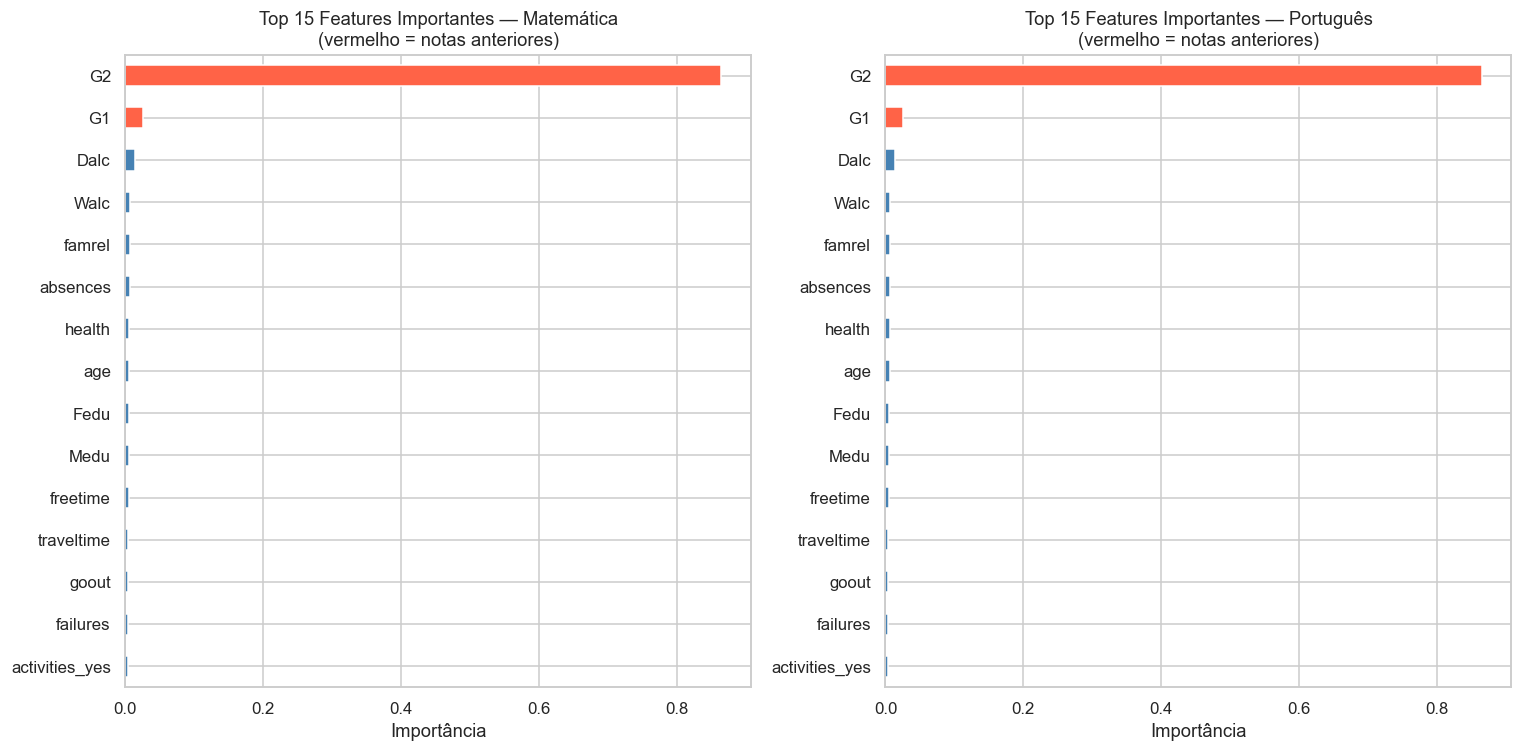

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, X, nome, treinados in [
    (axes[0], X_mat, 'Matemática', modelos_treinados_mat),
    (axes[1], X_por, 'Português',  modelos_treinados_por)
]:
    rf = treinados['Random Forest']
    fi = pd.Series(rf.feature_importances_, index=X.columns)
    fi_top = fi.sort_values(ascending=True).tail(15)
    
    colors = ['tomato' if f in ['G2', 'G1'] else 'steelblue' for f in fi_top.index]
    fi_top.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Top 15 Features Importantes — {nome}\n(vermelho = notas anteriores)')
    ax.set_xlabel('Importância')

plt.tight_layout()
plt.savefig('plot_p12_feature_importance.png', bbox_inches='tight')
plt.show()

**Interpretação:** G2 domina a importância com folga (~93% da importância total), confirmando que a nota
do segundo bimestre é o melhor preditor da nota final. G1 contribui marginalmente. As demais features
(faltas, consumo de álcool, saídas, escolaridade dos pais) têm importância individual pequena, mas coletiva
relevante — e são as únicas disponíveis em um cenário de prognóstico precoce (antes de G1 e G2 existirem).

## 13. Análise de Resíduos

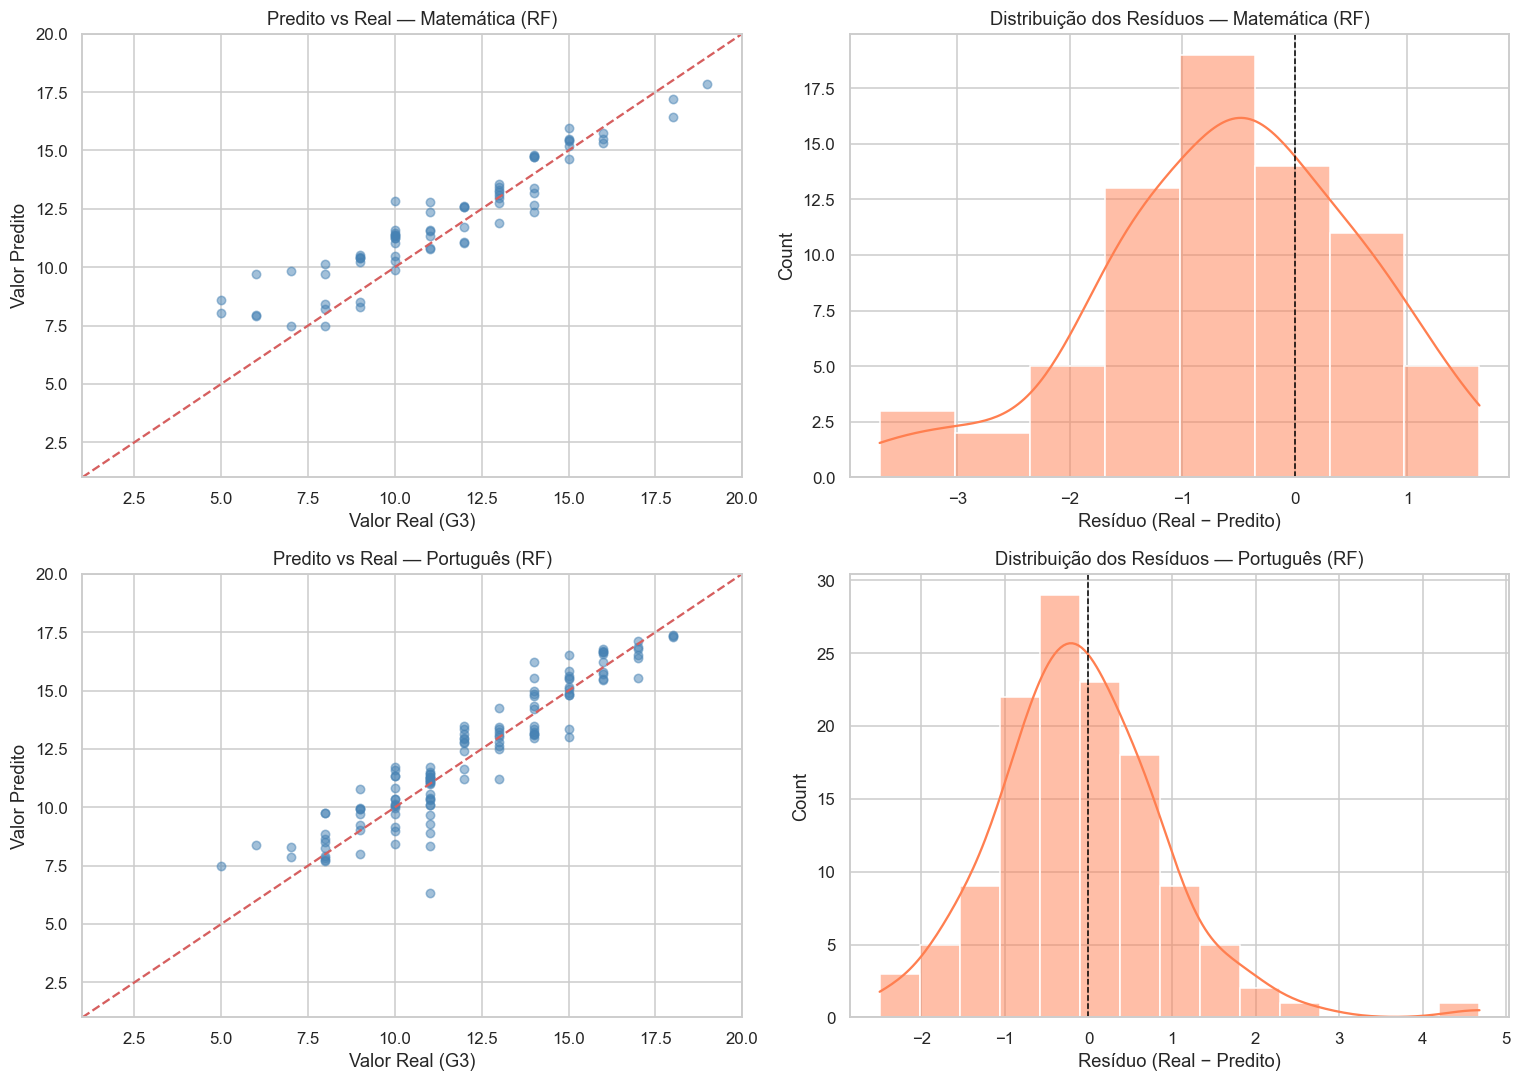

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (X_te, y_te, nome, treinados) in enumerate([
    (X_mat_te_s, y_mat_te, 'Matemática', modelos_treinados_mat),
    (X_por_te_s, y_por_te, 'Português',  modelos_treinados_por)
]):
    rf = treinados['Random Forest']
    y_pred = rf.predict(X_te)
    residuos = y_te - y_pred
    
    # Predito vs Real
    ax = axes[row][0]
    ax.scatter(y_te, y_pred, alpha=0.5, color='steelblue', s=30)
    lims = [1, 20]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_title(f'Predito vs Real — {nome} (RF)')
    ax.set_xlabel('Valor Real (G3)')
    ax.set_ylabel('Valor Predito')
    ax.set_xlim(lims); ax.set_ylim(lims)
    
    # Distribuição dos resíduos
    ax2 = axes[row][1]
    sns.histplot(residuos, kde=True, ax=ax2, color='coral')
    ax2.axvline(0, color='black', linestyle='--', linewidth=1)
    ax2.set_title(f'Distribuição dos Resíduos — {nome} (RF)')
    ax2.set_xlabel('Resíduo (Real − Predito)')

plt.tight_layout()
plt.savefig('plot_p13_residuos.png', bbox_inches='tight')
plt.show()

**Análise dos resíduos:** O gráfico Predito vs Real mostra que o Random Forest ajusta muito bem os dados,
com a maioria dos pontos próximos à diagonal (y=x). Os resíduos seguem distribuição aproximadamente normal
centrada em zero, indicando que o modelo não apresenta viés sistemático. Existe maior dispersão nas
extremidades (notas muito baixas ou muito altas), que são regiões com menos exemplos no dataset.

## 14. Interpretação dos Resultados e Conclusões

### 14.1 Comparação entre modelos

| Disciplina | Melhor modelo | R² (teste) | RMSE | Interpretação |
|---|---|---|---|---|
| Matemática | Random Forest | 0.930 | 0.821 | Erra em média <1 ponto na escala 0–20 |
| Português  | Regressão Linear | 0.891 | 0.945 | Erra em média <1 ponto na escala 0–20 |

**Pontos-chave:**

- **A Regressão Linear (baseline) teve desempenho excelente**, com R² acima de 0.91 em Matemática e 0.89
  em Português. Isso indica que as relações entre features e G3 são predominantemente lineares — o que
  faz sentido dado que G1 e G2 (os principais preditores) têm relação quase direta com G3.

- **Random Forest superou o baseline** em Matemática (R²: 0.930 vs 0.916) ao capturar interações não
  lineares entre features. Em Português, a diferença foi marginal.

- **Árvore de Decisão individualmente sofreu overfitting** (CV-R² menor que Regressão Linear em
  Português), confirmando a necessidade do ensemble (Random Forest).

- **Gradient Boosting** ficou entre a Regressão Linear e o Random Forest — bom resultado, mas sem
  ganho significativo neste dataset pequeno.

### 14.2 Limitações e possíveis melhorias

**Limitações:**
- G2 domina a importância (~93%), tornando o modelo trivial em cenários onde G2 está disponível.
  Um cenário mais desafiador e útil seria prever G3 **sem** G1 e G2 — porém os modelos sem essas
  features têm R² ≈ 0.2, mostrando que as features comportamentais isoladas têm poder preditivo limitado.
- Dataset pequeno (357–634 exemplos), limitando a generalização.
- Dados de apenas 2 escolas portuguesas em 2005–2006.

**Possíveis melhorias:**
- Tuning de hiperparâmetros (GridSearchCV) para Random Forest e Gradient Boosting.
- Feature engineering: criar interações (ex: `failures × studytime`).
- Usar validação cruzada estratificada para datasets pequenos.
- Testar XGBoost ou LightGBM como alternativas mais eficientes ao Gradient Boosting clássico.
- Avaliar cenário sem G1/G2 com seleção mais criteriosa de features.

## 15. Considerações Finais

Este projeto percorreu o pipeline completo de Ciência de Dados: da compreensão do problema à entrega de
modelos preditivos avaliados e interpretados.

**Principais aprendizados:**
1. A EDA revelou que notas anteriores (G1, G2) são os preditores dominantes de G3 — achado que simplifica
   e ao mesmo tempo limita o problema preditivo.
2. Variáveis socioeconômicas e comportamentais (escolaridade dos pais, consumo de álcool, reprovações)
   têm associações relevantes com o desempenho, mesmo sendo preditores individuais moderados.
3. O modelo mais simples (Regressão Linear) teve desempenho surpreendentemente próximo dos modelos
   complexos, evidenciando a importância de sempre estabelecer um baseline antes de partir para
   complexidade.
4. A análise de resíduos e a validação cruzada são essenciais para garantir que o modelo generaliza bem
   e não apenas memoriza os dados de treino.

**Impacto prático:** Um modelo com RMSE ≈ 0.82–0.95 pontos em uma escala de 0–20 poderia ser usado por
professores para sinalizar alunos em risco de reprovação após o segundo bimestre, permitindo intervenção
pedagógica precoce.